# Australian Population Statistics

## Import Libraries

In [1]:
import pandas as pd
from API_call import abs_download_csv
from matplotlib import pyplot as plt

## Download Births Dataset

In [2]:
births = abs_download_csv(
    dataflow = "ABS,BIRTHS_MONTH_OCCURRENCE,1.0.0",
    key = "1...A"
)

## Filter Dataset

In [3]:
filtered_births=births[(births['MONTH_OCCUR: Month of occurence']=='TOT: Total') &
                (births['REGION: Region']=='AUS: Australia') &
                (births['FREQ: Frequency']=='A: Annual')
]

## Drop Columns

In [4]:

filtered_births.drop(columns=['DATAFLOW','MEASURE: Measure',
                              'UNIT_MEASURE: Unit of Measure',
                              'OBS_STATUS: Observation Status',
                              'OBS_COMMENT: Observation Comment',
                              'MONTH_OCCUR: Month of occurence',
                              'REGION: Region',
                              'FREQ: Frequency'],inplace=True)


## Rename Columns

In [5]:
filtered_births=filtered_births.rename(columns={
    'TIME_PERIOD: Time Period':'year',
    'OBS_VALUE':'births'})
filtered_births = filtered_births.reset_index(drop=True)

## Births Visualization

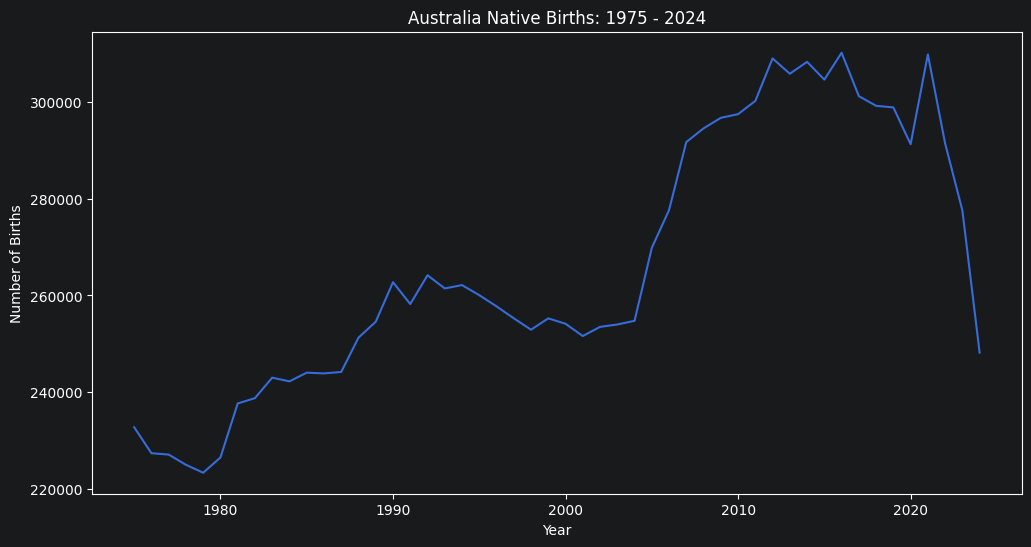

In [6]:
plt.figure(figsize=(12,6))
plt.title('Australia Native Births: 1975 - 2024')
x=filtered_births['year']
y=filtered_births['births']
plt.plot(x,y)
plt.xlabel('Year')
plt.ylabel('Number of Births')
plt.show()

## Download Deaths Dataset

In [7]:
deaths = abs_download_csv(
    dataflow = "ABS,DEATHS_AGESPECIFIC_REGISTRATIONYEAR_1,1.0.0",
    key = "4...AUS.A"
)

## Filter Dataset

In [8]:
filtered_deaths=deaths[(deaths['SEX: Sex']=='3: Persons') &
                (deaths['REGION: Region']=='AUS: Australia') &
                (deaths['FREQ: Frequency']=='A: Annual') &
                (deaths['AGE: Age'] == 'TOT: All ages')
]

## Dropping Columns

In [9]:
filtered_deaths.drop(columns=['DATAFLOW', 'MEASURE: Measure',
                              'UNIT_MEASURE: Unit of Measure',
                              'OBS_STATUS: Observation Status',
                              'OBS_COMMENT: Observation Comment',
                              'REGION: Region',
                              'SEX: Sex',
                              'AGE: Age',
                              'FREQ: Frequency'], inplace=True)

## Renaming columns and dropping rows that will not be used for analysis
### The dimension of the dataset is reduced to only include the year, deaths, and births columns. Rows with missing data are also dropped.

In [10]:
filtered_deaths=filtered_deaths.rename(columns={
    'TIME_PERIOD: Time Period':'year',
    'OBS_VALUE':'deaths'})
filtered_deaths = filtered_deaths.reset_index(drop=True)
filtered_deaths=filtered_deaths[4:]
filtered_deaths = filtered_deaths.reset_index(drop=True)

## Visualize Deaths

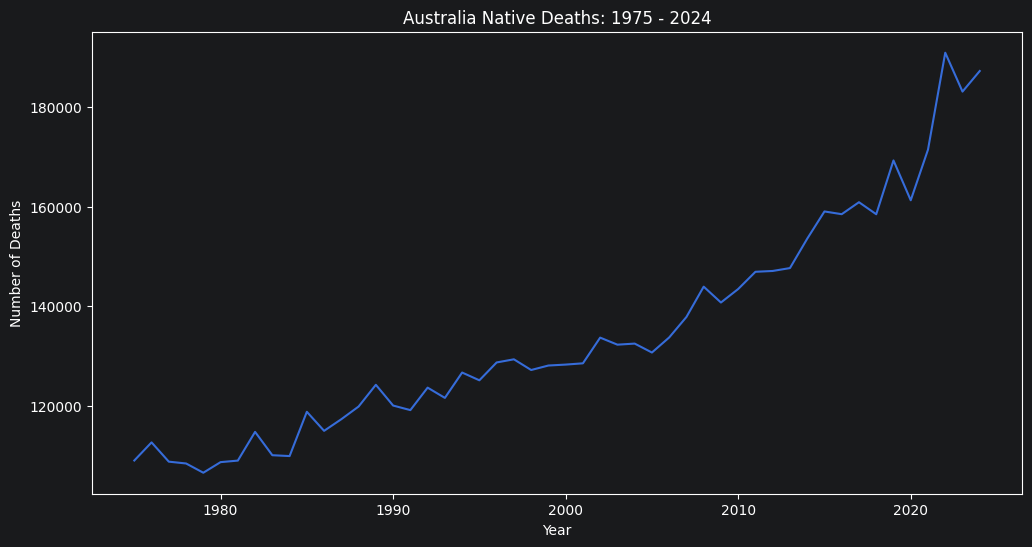

In [11]:
plt.figure(figsize=(12,6))
plt.title('Australia Native Deaths: 1975 - 2024')
x=filtered_deaths['year']
y=filtered_deaths['deaths']
plt.plot(x,y)
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.show()

## Merging Births and Deaths Dataframes

In [12]:
merged_df = pd.merge(filtered_births, filtered_deaths, on='year')
merged_df['net_native_growth']= merged_df['births']-merged_df['deaths']

## Visualize Net Native Population Growth

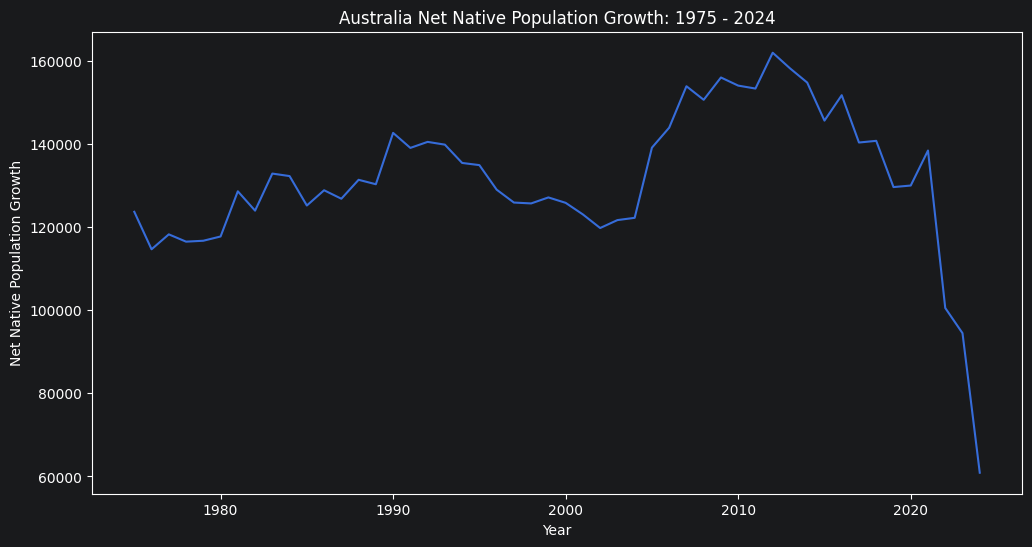

In [13]:
plt.figure(figsize=(12,6))
plt.title('Australia Net Native Population Growth: 1975 - 2024')
x=merged_df['year']
y=merged_df['net_native_growth']
plt.plot(x,y)
plt.xlabel('Year')
plt.ylabel('Net Native Population Growth')
plt.show()